### Import required Library

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import  train_test_split
from sklearn.metrics import mean_absolute_error,mean_squared_error,root_mean_squared_error,r2_score
import statsmodels.formula.api as smf
import statsmodels.api as sns
from pickle import dump,load

import warnings
warnings.filterwarnings("ignore")


In [1]:
pip install scikit-learn

   ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.9 MB 4.2 MB/s eta 0:00:02
   ------- -------------------------------- 1.6/8.9 MB 5.2 MB/s eta 0:00:02
   ----------- ---------------------------- 2.6/8.9 MB 4.4 MB/s eta 0:00:02
   -------------------- ------------------- 4.5/8.9 MB 6.0 MB/s eta 0:00:01
   ---------------------------- ----------- 6.3/8.9 MB 6.0 MB/s eta 0:00:01
   ------------------------------- -------- 7.1/8.9 MB 5.6 MB/s eta 0:00:01
   -------------------------------------- - 8.7/8.9 MB 6.0 MB/s eta 0:00:01
   ---------------------------------------- 8.9/8.9 MB 5.4 MB/s  0:00:01
   ---------------------------------------- 0.0/41.3 MB ? eta -:--:--
    --------------------------------------- 0.5/41.3 MB 1.9 MB/s eta 0:00:22
   - -------------------------------------- 1.3/41.3 MB 2.7 MB/s eta 0:00:15
   - ----------------------------

### 1. Data Collection

In [3]:
Cars_dataset = pd.read_csv("Cars.csv")
Cars_dataset

,HP,MPG,VOL,SP,WT
0,49,53.700681,89,104.185353,28.762059
1,55,50.013401,92,105.461264,30.466833
2,55,50.013401,92,105.461264,30.193597
3,70,45.696322,92,113.461264,30.632114
4,53,50.504232,92,104.461264,29.889149
...,...,...,...,...,...
76,322,36.900000,50,169.598513,16.132947
77,238,19.197888,115,150.576579,37.923113
78,263,34.000000,50,151.598513,15.769625
79,295,19.833733,119,167.944460,39.423099


### 2. Data Understanding

In [4]:
Cars_dataset.shape

(81, 5)

In [5]:
Cars_dataset.isna().sum()

HP     0
MPG    0
VOL    0
SP     0
WT     0
dtype: int64

In [6]:
Cars_dataset.dtypes

HP       int64
MPG    float64
VOL      int64
SP     float64
WT     float64
dtype: object

In [7]:
Cars_dataset.describe()

,HP,MPG,VOL,SP,WT
count,81.000000,81.000000,81.000000,81.000000,81.000000
mean,117.469136,34.422076,98.765432,121.540272,32.412577
std,57.113502,9.131445,22.301497,14.181432,7.492813
min,49.000000,12.101263,50.000000,99.564907,15.712859
25%,84.000000,27.856252,89.000000,113.829145,29.591768
50%,100.000000,35.152727,101.000000,118.208698,32.734518
75%,140.000000,39.531633,113.000000,126.404312,37.392524
max,322.000000,53.700681,160.000000,169.598513,52.997752


#### 2.1 check Data Assumptions

#### Linearity Test

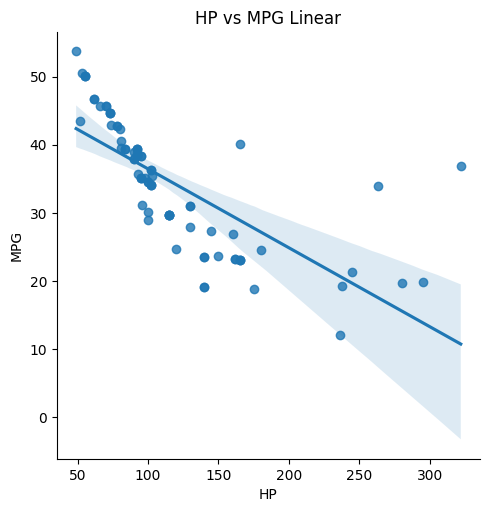

In [8]:
sns.lmplot(Cars_dataset,x="HP",y="MPG")
plt.title("HP vs MPG Linear")
plt.show()

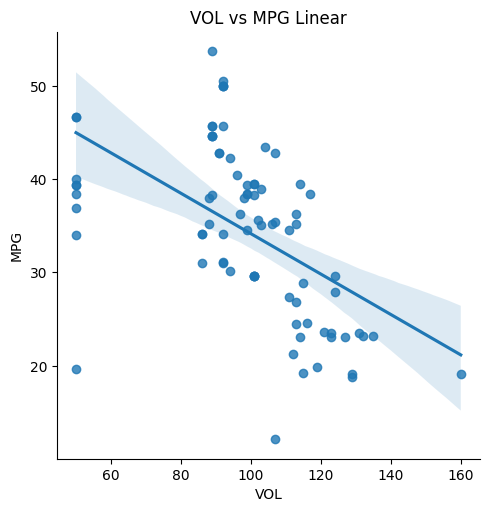

In [9]:
sns.lmplot(Cars_dataset,x="VOL",y="MPG")
plt.title("VOL vs MPG Linear")
plt.show()

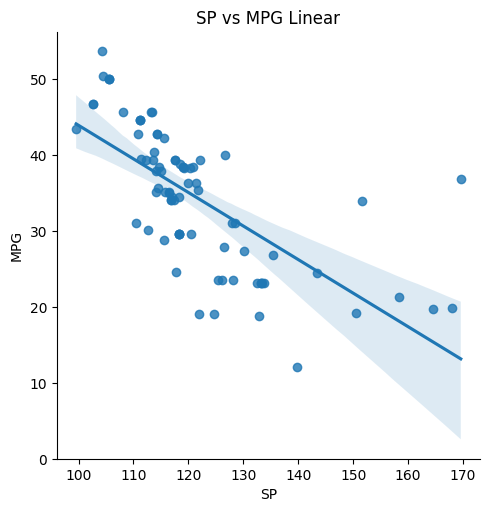

In [10]:
sns.lmplot(Cars_dataset,x="SP",y="MPG")
plt.title("SP vs MPG Linear")
plt.show()

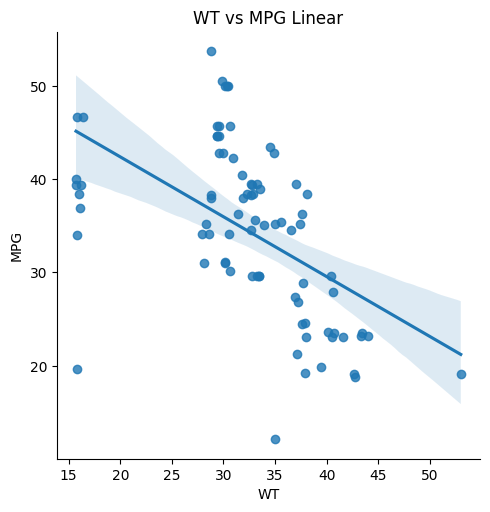

In [11]:
sns.lmplot(Cars_dataset,x="WT",y="MPG")
plt.title("WT vs MPG Linear")
plt.show()

#### Linearity Test Failed

###  Normality Test (Histogram distribution of Input Feature)

In [12]:
Cars_dataset.head()

,HP,MPG,VOL,SP,WT
0,49,53.700681,89,104.185353,28.762059
1,55,50.013401,92,105.461264,30.466833
2,55,50.013401,92,105.461264,30.193597
3,70,45.696322,92,113.461264,30.632114
4,53,50.504232,92,104.461264,29.889149


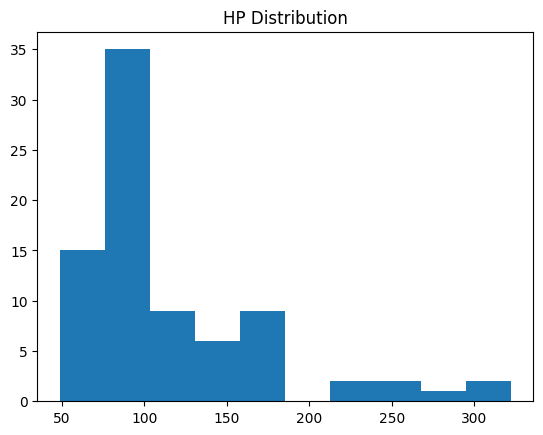

In [13]:
plt.hist(Cars_dataset["HP"])
plt.title("HP Distribution")
plt.show()

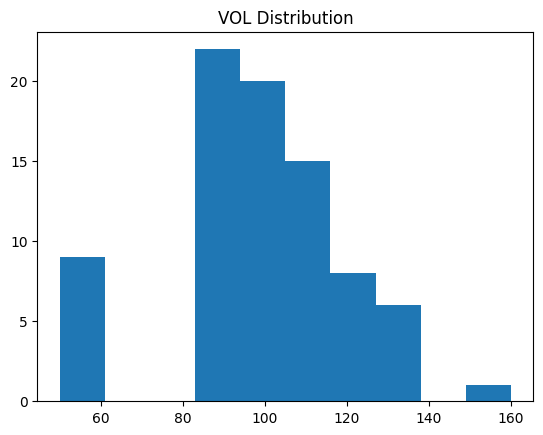

In [14]:
plt.hist(Cars_dataset["VOL"])
plt.title("VOL Distribution")
plt.show()

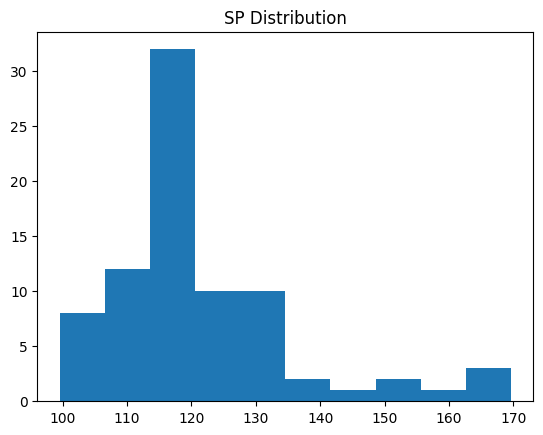

In [15]:
plt.hist(Cars_dataset["SP"])
plt.title("SP Distribution")
plt.show()

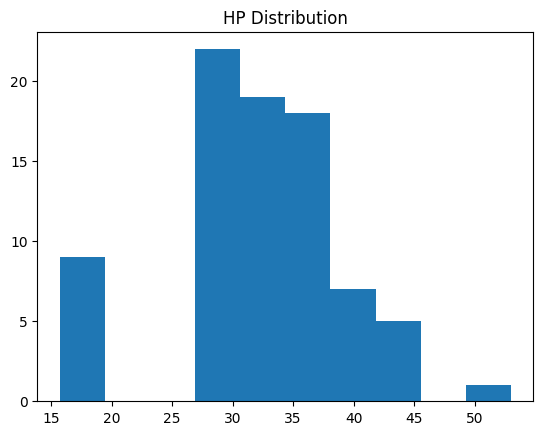

In [16]:
plt.hist(Cars_dataset["WT"])
plt.title("HP Distribution")
plt.show()

#### Normality Test Failed

### Coleinearity Test(Co-Relarion Matrix)

In [17]:
Cars_dataset.corr()

,HP,MPG,VOL,SP,WT
HP,1.000000,-0.725038,0.077459,0.973848,0.076513
MPG,-0.725038,1.000000,-0.529057,-0.687125,-0.526759
VOL,0.077459,-0.529057,1.000000,0.102170,0.999203
SP,0.973848,-0.687125,0.102170,1.000000,0.102439
WT,0.076513,-0.526759,0.999203,0.102439,1.000000


<Axes: >

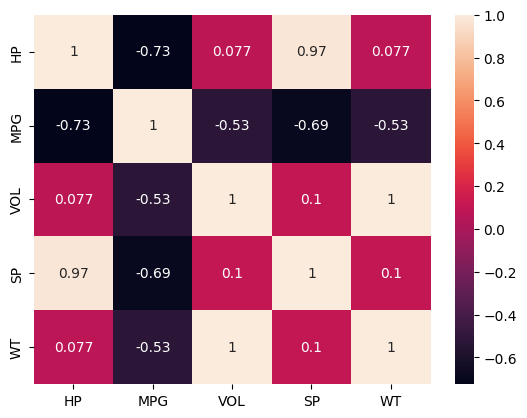

In [18]:
sns.heatmap(Cars_dataset.corr(),annot=True)

In [19]:
##  VOL and WT are Highly Corelated
## SP and HP are Highly Co-related
## Co Multicollinearity Exixt
## Auto Regration(Timeline[time, date] is not exist

## Note : Homoscadacity and Zero Residual mean test will perform  during Module Test

### 3. Data Prepation

In [19]:
Cars_dataset

,HP,MPG,VOL,SP,WT
0,49,53.700681,89,104.185353,28.762059
1,55,50.013401,92,105.461264,30.466833
2,55,50.013401,92,105.461264,30.193597
3,70,45.696322,92,113.461264,30.632114
4,53,50.504232,92,104.461264,29.889149
...,...,...,...,...,...
76,322,36.900000,50,169.598513,16.132947
77,238,19.197888,115,150.576579,37.923113
78,263,34.000000,50,151.598513,15.769625
79,295,19.833733,119,167.944460,39.423099


In [20]:
X = Cars_dataset[["HP","VOL","SP","WT"]]

In [21]:
y = Cars_dataset["MPG"]

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X,y,train_size = 0.80,random_state=30)

In [23]:
X_train

,HP,VOL,SP,WT
39,130,92,128.461264,30.115434
48,130,86,127.909442,28.070597
21,74,107,110.840817,34.908211
66,165,114,132.484609,37.979956
58,100,94,112.645204,30.615283
...,...,...,...,...
12,92,99,122.105055,32.813592
78,263,50,151.598513,15.769625
45,100,99,117.105055,32.621916
80,236,107,139.840817,34.948615


### 4. Module Building

In [24]:
linear_model = LinearRegression()

### 5. Module Training

In [25]:
linear_model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [26]:
linear_model.coef_

array([-0.20434313, -0.29774244,  0.4421769 ,  0.25016278])

In [27]:
linear_model.intercept_

np.float64(26.064998965923674)

### 7. Module Testing

In [80]:
y_actual = linear_model.predict(X)

In [67]:
y_predict = linear_model.predict(X_train)

In [68]:
y_predict_test = linear_model.predict(X_test)

### 8. Module Evalution

In [31]:
error = y-y_predict
error

0     10.258747
1      7.624608
2      7.734060
3      3.157963
4      8.331584
        ...    
76    15.617904
77     1.298838
78     7.863547
79     7.517122
80    -3.458218
Name: MPG, Length: 81, dtype: float64

In [32]:
### Perform the Homoscadacity and Zero Residual Test

In [ ]:
### Module Evalution Metrics

In [61]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,root_mean_squared_error,r2_score
import statsmodels.formula.api as smf
import statsmodels.api as sns

In [30]:
mean_squared_error(y_train,y_predict)

19.19823666398488

In [31]:
mean_absolute_error(y_train,y_predict)

3.3748042232398463

In [33]:
root_mean_squared_error(y_train,y_predict)

4.38157924314794

In [35]:
r2_score(y_train,y_predict)

0.7528081609421928

In [41]:
Cars_dataset.head()

,HP,MPG,VOL,SP,WT
0,49,53.700681,89,104.185353,28.762059
1,55,50.013401,92,105.461264,30.466833
2,55,50.013401,92,105.461264,30.193597
3,70,45.696322,92,113.461264,30.632114
4,53,50.504232,92,104.461264,29.889149


In [44]:
smf_module = smf.ols(formula = "MPG~HP", data = Cars_dataset).fit() ## Ordinary Least Square

In [45]:
smf_module.predict(X_train)

39    32.969487
48    32.969487
21    39.461056
66    28.912256
58    36.447113
        ...    
12    37.374480
78    17.552009
45    36.447113
80    20.681873
37    36.215272
Length: 64, dtype: float64

In [50]:
print("R2 Scode : ",smf_module.rsquared.round(4), "\n Adjusted R2 Score: ",smf_module.rsquared_adj.round(4))

R2 Scode :  0.5257 
 Adjusted R2 Score:  0.5197


In [53]:
smf_module = smf.ols(formula = "MPG~HP+VOL", data = Cars_dataset).fit()
smf_module.predict(X_train)

39    34.361209
48    35.529996
21    37.600865
66    26.224641
58    37.272483
        ...    
12    37.178726
78    27.908863
45    36.298494
80    19.776167
37    38.610809
Length: 64, dtype: float64

In [52]:
print("R2 Scode : ",smf_module.rsquared.round(4), "\n Adjusted R2 Score: ",smf_module.rsquared_adj.round(4))

R2 Scode :  0.7507 
 Adjusted R2 Score:  0.7443


In [54]:
smf_module = smf.ols(formula = "MPG~HP+VOL+SP", data = Cars_dataset).fit()

In [55]:
print("R2 Scode : ",smf_module.rsquared.round(4), "\n Adjusted R2 Score: ",smf_module.rsquared_adj.round(4))

R2 Scode :  0.7704 
 Adjusted R2 Score:  0.7614


In [56]:
smf_module = smf.ols(formula = "MPG~HP+VOL+SP+WT", data = Cars_dataset).fit()

In [57]:
print("R2 Scode : ",smf_module.rsquared.round(4), "\n Adjusted R2 Score: ",smf_module.rsquared_adj.round(4))

R2 Scode :  0.7705 
 Adjusted R2 Score:  0.7585


In [59]:
y_r2_Predict = smf_module.predict(X_train)

In [64]:
smf_module = sns.OLS(y_train,X_train).fit()

In [76]:
print(smf_module.rsquared,smf_module.rsquared_adj)

0.9843416312576372 0.9832977400081463


In [ ]:
### Test Module Evalution 

In [69]:
mean_squared_error(y_test,y_predict_test)

20.416377600355418

In [70]:
mean_absolute_error(y_test,y_predict_test)

3.275227179780683

In [71]:
root_mean_squared_error(y_test,y_predict_test)

4.518448583347543

In [72]:
smf_test = sns.OLS(y_test,X_test).fit()

In [75]:
print(smf_test.rsquared.round(4),smf_test.rsquared_adj.round(4))

0.9949 0.9933


In [ ]:
### Actual Data Set

In [77]:
smf_Actual  = sns.OLS(y,X).fit()

In [79]:
print(smf_Actual.rsquared.round(4),smf_Actual.rsquared_adj.round(4))

0.9843 0.9834


In [87]:
smf_Actual  = sns.OLS(y,X).fit()

In [88]:
print(smf_Actual.rsquared.round(4),smf_Actual.rsquared_adj.round(4))

0.9843 0.9834


In [83]:
r2_score(y,y_actual)

0.7637767561000843

In [84]:
mean_squared_error(y,y_actual)

19.45389587285277

In [85]:
mean_absolute_error(y,y_actual)

3.3539053375755774

In [86]:
root_mean_squared_error(y,y_actual)

4.410657079489718

<Axes: xlabel='HP', ylabel='MPG'>

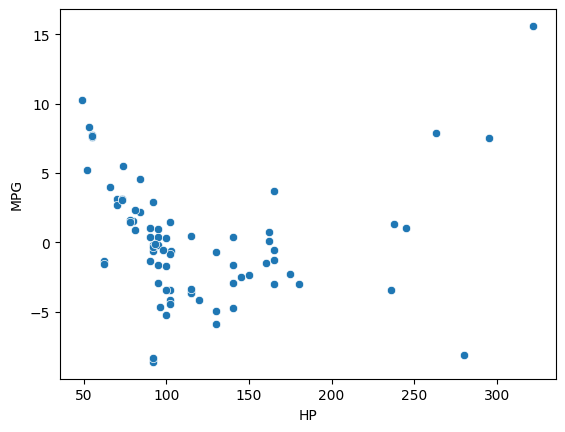

In [35]:
sns.scatterplot(data= Cars_dataset,x="HP",y=error)

In [36]:
Cars_dataset.head()

,HP,MPG,VOL,SP,WT
0,49,53.700681,89,104.185353,28.762059
1,55,50.013401,92,105.461264,30.466833
2,55,50.013401,92,105.461264,30.193597
3,70,45.696322,92,113.461264,30.632114
4,53,50.504232,92,104.461264,29.889149


<Axes: xlabel='VOL', ylabel='MPG'>

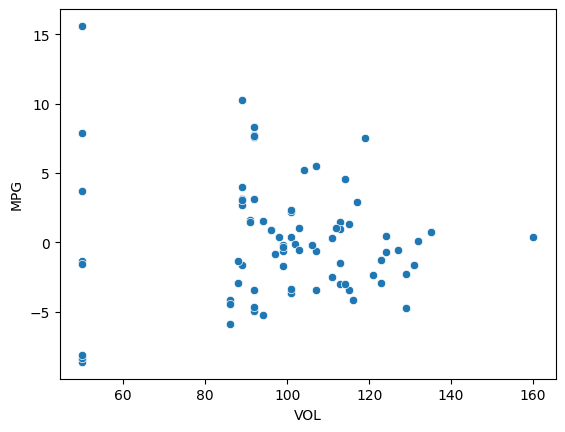

In [37]:
sns.scatterplot(data = Cars_dataset,x = "VOL",y = error)

<Axes: xlabel='SP', ylabel='MPG'>

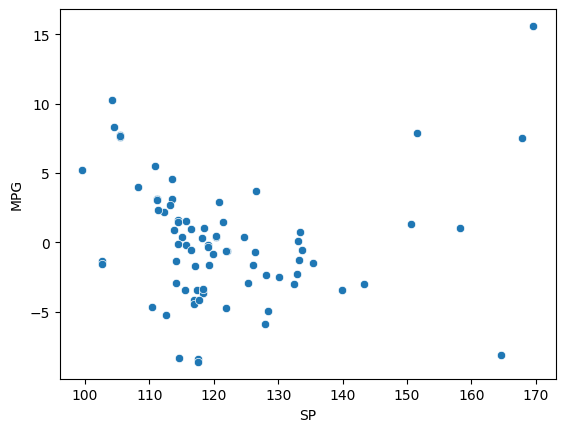

In [38]:
sns.scatterplot(data = Cars_dataset,x = "SP",y = error)

<Axes: xlabel='WT', ylabel='MPG'>

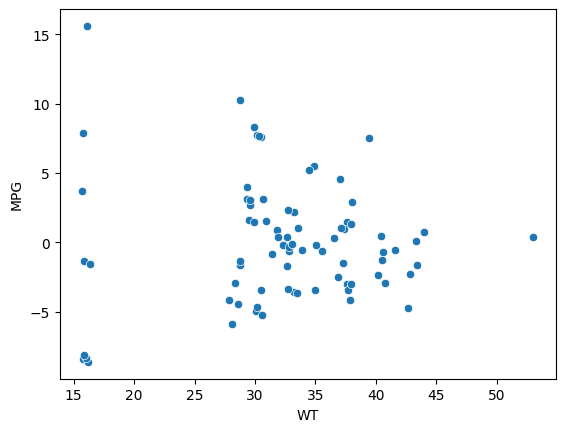

In [39]:
sns.scatterplot(data = Cars_dataset,x = "WT",y = error)

#### Homescadacity Failes

### Zero Residus Test

<Axes: xlabel='MPG'>

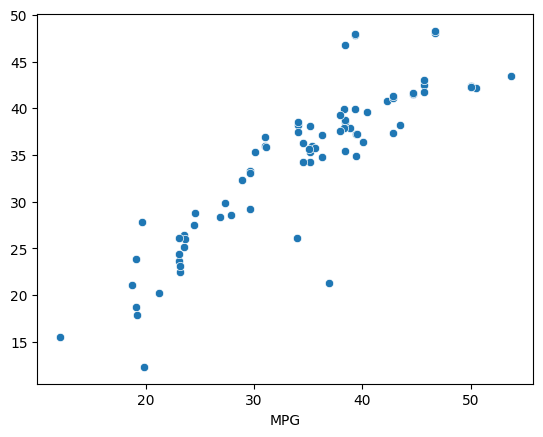

In [40]:
sns.scatterplot(x=y,y=y_predict)

####  Zero residus also Failes

### 9. Module Deployment

In [44]:
dump(obj = linear_model, file = open("linear_reg.pkl",mode="wb"))

In [46]:
linear_intel_pkl = load(file=open("linear_reg.pkl",mode="rb"))

In [47]:
linear_intel_pkl.predict(X)

array([43.44193477, 42.38879289, 42.27934147, 42.53835981, 42.17264802,
       43.02061916, 42.32536062, 48.07621852, 48.28120247, 40.79122814,
       41.52153227, 47.80956747, 39.95980269, 41.52757889, 41.76632332,
       41.6181448 , 41.15094046, 47.98605515, 41.30861046, 37.87127922,
       38.57706414, 37.35199705, 37.89770285, 39.5625144 , 39.93380662,
       46.73870908, 35.48165898, 38.78152504, 38.24861192, 36.00285298,
       34.84603989, 37.21630246, 37.13919796, 34.82541399, 37.22361389,
       37.53950097, 39.27144845, 38.24219888, 38.54286458, 35.9391722 ,
       34.2129755 , 35.36313259, 37.50473376, 38.07998482, 35.79651664,
       36.2613377 , 34.21826465, 35.59393404, 36.91805291, 33.31108154,
       33.21313413, 33.3023649 , 29.19864884, 27.52358579, 28.3207133 ,
       28.56722621, 35.81583602, 33.02108459, 35.37334971, 32.29909503,
       29.87685849, 28.76093817, 25.14188416, 26.47040896, 25.97651933,
       36.35652478, 26.0975912 , 23.6416178 , 24.39887199, 20.21

### =======================================  END =====================================